# Case Study 2: Credit Card Fraud Detection using XGBoost & SMOTE
This notebook demonstrates a complete workflow to handle heavily imbalanced credit card transactions, apply SMOTE (Synthetic Minority Over-sampling Technique), train an XGBoost model, optimize the decision threshold, and interpret the feature importances.

In [1]:
# Install necessary libraries
!pip install -q imbalanced-learn xgboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Download and Load Dataset
We will use the standard Kaggle **Credit Card Fraud Detection** dataset. Since accessing the Kaggle API directly requires credentials, we will provide a helper script to automatically download the dataset from a public mirror if it is not already present locally.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request


url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
csv_path = "creditcard.csv"

if not os.path.exists(csv_path):
    print("Downloading creditcard.csv...")
    urllib.request.urlretrieve(url, csv_path)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

df = pd.read_csv(csv_path)
display(df.head())


print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"Percentage of fraudulent transactions: {df['Class'].mean() * 100:.4f}%")

Download complete.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Percentage of fraudulent transactions: 0.1727%


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df[df.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

### 2. Train-Test Split & SMOTE (Oversampling)
To avoid data leakage, we first split our dataset into training and testing sets, then apply SMOTE **only** to our training set.

In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler


X = df.drop(columns=['Class'])
y = df['Class']


scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape} with {y_train.sum()} frauds")
print(f"Resampled training shape: {X_train_res.shape} with {y_train_res.sum()} frauds")

Original training shape: (226980, 30) with 378 frauds
Resampled training shape: (453204, 30) with 226602 frauds


### 3. Model Training (XGBoost)
We train an XGBoost classifier on the SMOTE-balanced training dataset.

In [10]:
import xgboost as xgb


xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_res, y_train_res)

print("XGBoost model training completed.")

c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:26:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training completed.


In [11]:
y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test,y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9991012582384662
Precision: 0.7115384615384616
Recall   : 0.7789473684210526
F1 Score : 0.7437185929648241
ROC-AUC  : 0.9586503327390513


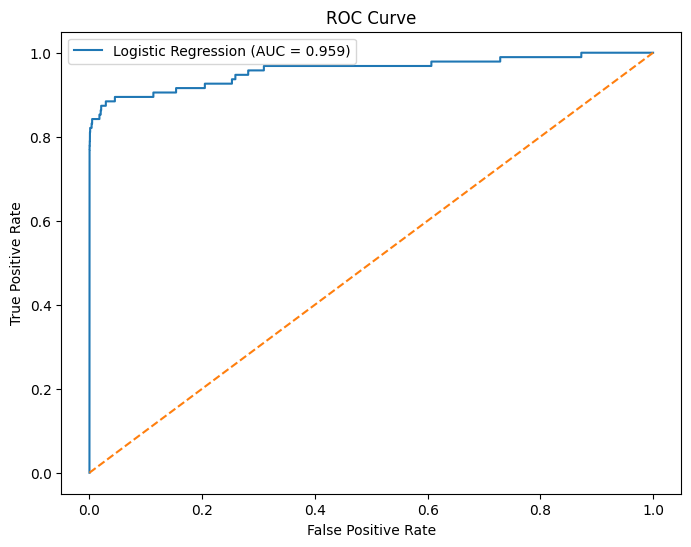

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### 4. Evaluate Threshold Tuning
By default, classifiers predict positive instances at a threshold of 0.5. For fraud detection, we often want a lower threshold to catch more fraudulent cases (higher recall), even if it yields some false alarms (lower precision).

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt

y_probs = xgb_clf.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

for th in thresholds:
    y_pred_th = (y_probs >= th).astype(int)
    print(f"\n--- Classification Report at Threshold: {th} ---")
    print(classification_report(y_test, y_pred_th))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_th))


--- Classification Report at Threshold: 0.1 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.45      0.82      0.58        95

    accuracy                           1.00     56746
   macro avg       0.72      0.91      0.79     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56555    96]
 [   17    78]]

--- Classification Report at Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.60      0.81      0.69        95

    accuracy                           1.00     56746
   macro avg       0.80      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56600    51]
 [   18    77]]

--- Classification Report at Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   

In [16]:
from sklearn.metrics import roc_auc_score,average_precision_score

print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print("PR-AUC:", average_precision_score(y_test, y_probs))

ROC-AUC: 0.9586503327390513
PR-AUC: 0.8049245967287572


### 5. Interpret Results: Feature Importance
Let's plot which features were most influential to the XGBoost model.

C:\Users\moham\AppData\Local\Temp\ipykernel_18280\1071450644.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


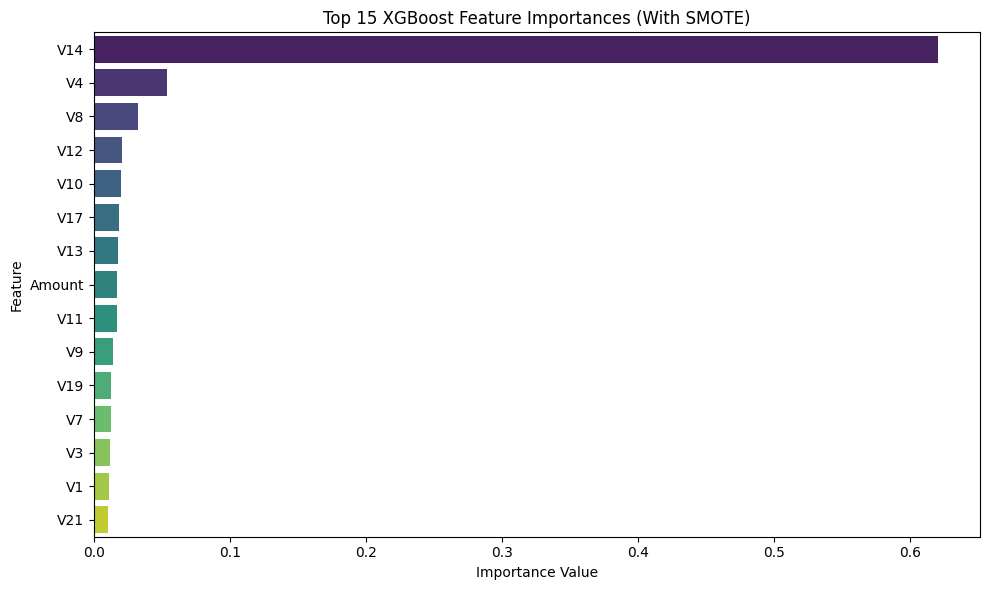

In [17]:
import seaborn as sns


importances = xgb_clf.feature_importances_
feature_names = X.columns


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 15 XGBoost Feature Importances (With SMOTE)')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_clf.feature_importances_
})

coefficients = coefficients.sort_values(
    by="Importance",
    ascending=False
)

coefficients

,Feature,Importance
14,V14,0.620344
4,V4,0.053695
8,V8,0.032552
12,V12,0.020745
10,V10,0.020314
17,V17,0.018316
13,V13,0.017926
29,Amount,0.017147
11,V11,0.016911
9,V9,0.013933


In [19]:
predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Predicted_Probability": y_prob
})

predictions_df.insert(0, "Transaction_ID", y_test.index)

predictions_df.head()

,Transaction_ID,Actual,Predicted,Predicted_Probability
0,86568,0,0,5.346055e-07
1,251557,0,0,1.807967e-06
2,20232,0,0,2.080703e-05
3,68952,0,0,1.452923e-06
4,191852,0,0,9.001851e-04


In [20]:
predictions_df.to_csv("Credit_Card_Fraud_Detection_predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [22]:
check_predictions_df = pd.read_csv('Credit_Card_Fraud_Detection_predictions.csv')

print(check_predictions_df.shape)
check_predictions_df.head()

(56746, 4)


,Transaction_ID,Actual,Predicted,Predicted_Probability
0,86568,0,0,5.346055e-07
1,251557,0,0,1.807967e-06
2,20232,0,0,2.080703e-05
3,68952,0,0,1.452923e-06
4,191852,0,0,9.001851e-04
